In [1]:
using Random
using Statistics
using CairoMakie

# **Langevin Dynamics Tutorial**

Recall the Langevin equation:

$$
\dot{\mathbf{v}} = -\nabla\Phi(\mathbf{v}) + \sqrt{2}\dot{\mathbf{W}}.
$$

The Euler-Maruyama discretization scheme for the above equation is:

$$
\mathbf{v}_{i+1} = \mathbf{v}_i - \Delta t\nabla\Phi(\mathbf{v}_i) + \sqrt{2\Delta t}\boldsymbol{\xi}_i,
$$
where $\boldsymbol{\xi}_i\sim\mathcal{N}(\boldsymbol{0},\mathbf{I})$ and $\Delta t$ is the step size. Let's see this in action with a few simple examples.

## **Example 1**

In this example, we study:

$$
\dot{\mathbf{v}} = -\mathbf{v} + \sqrt{2}\dot{\mathbf{W}}.
$$
As we saw, this Langevin equation has the invariant distribution:

$$
\rho_\infty\propto \exp\left\{-\frac{1}{2}\|\mathbf{v}\|^2\right\} \equiv \mathcal{N}(\boldsymbol{0},\mathbf{I})
$$

In [114]:
Φ(v) = (1/2)*(v^2)
∇Φ(v) = v

function Langevin_EM(; Δt = 1e-3, J = 2_000_000, v₀ = 0.0)
    v = v₀
    σ = sqrt(2*Δt)
    out = Float64[]

    for j = 1:J
        v += -Δt*∇Φ(v) + σ*randn()
        push!(out,v)

    end
    return out
    
end

Δt = 1e-3
J = 2_000_000
v₀ = 2.0
vs = Langevin_EM(; Δt, J, v₀);

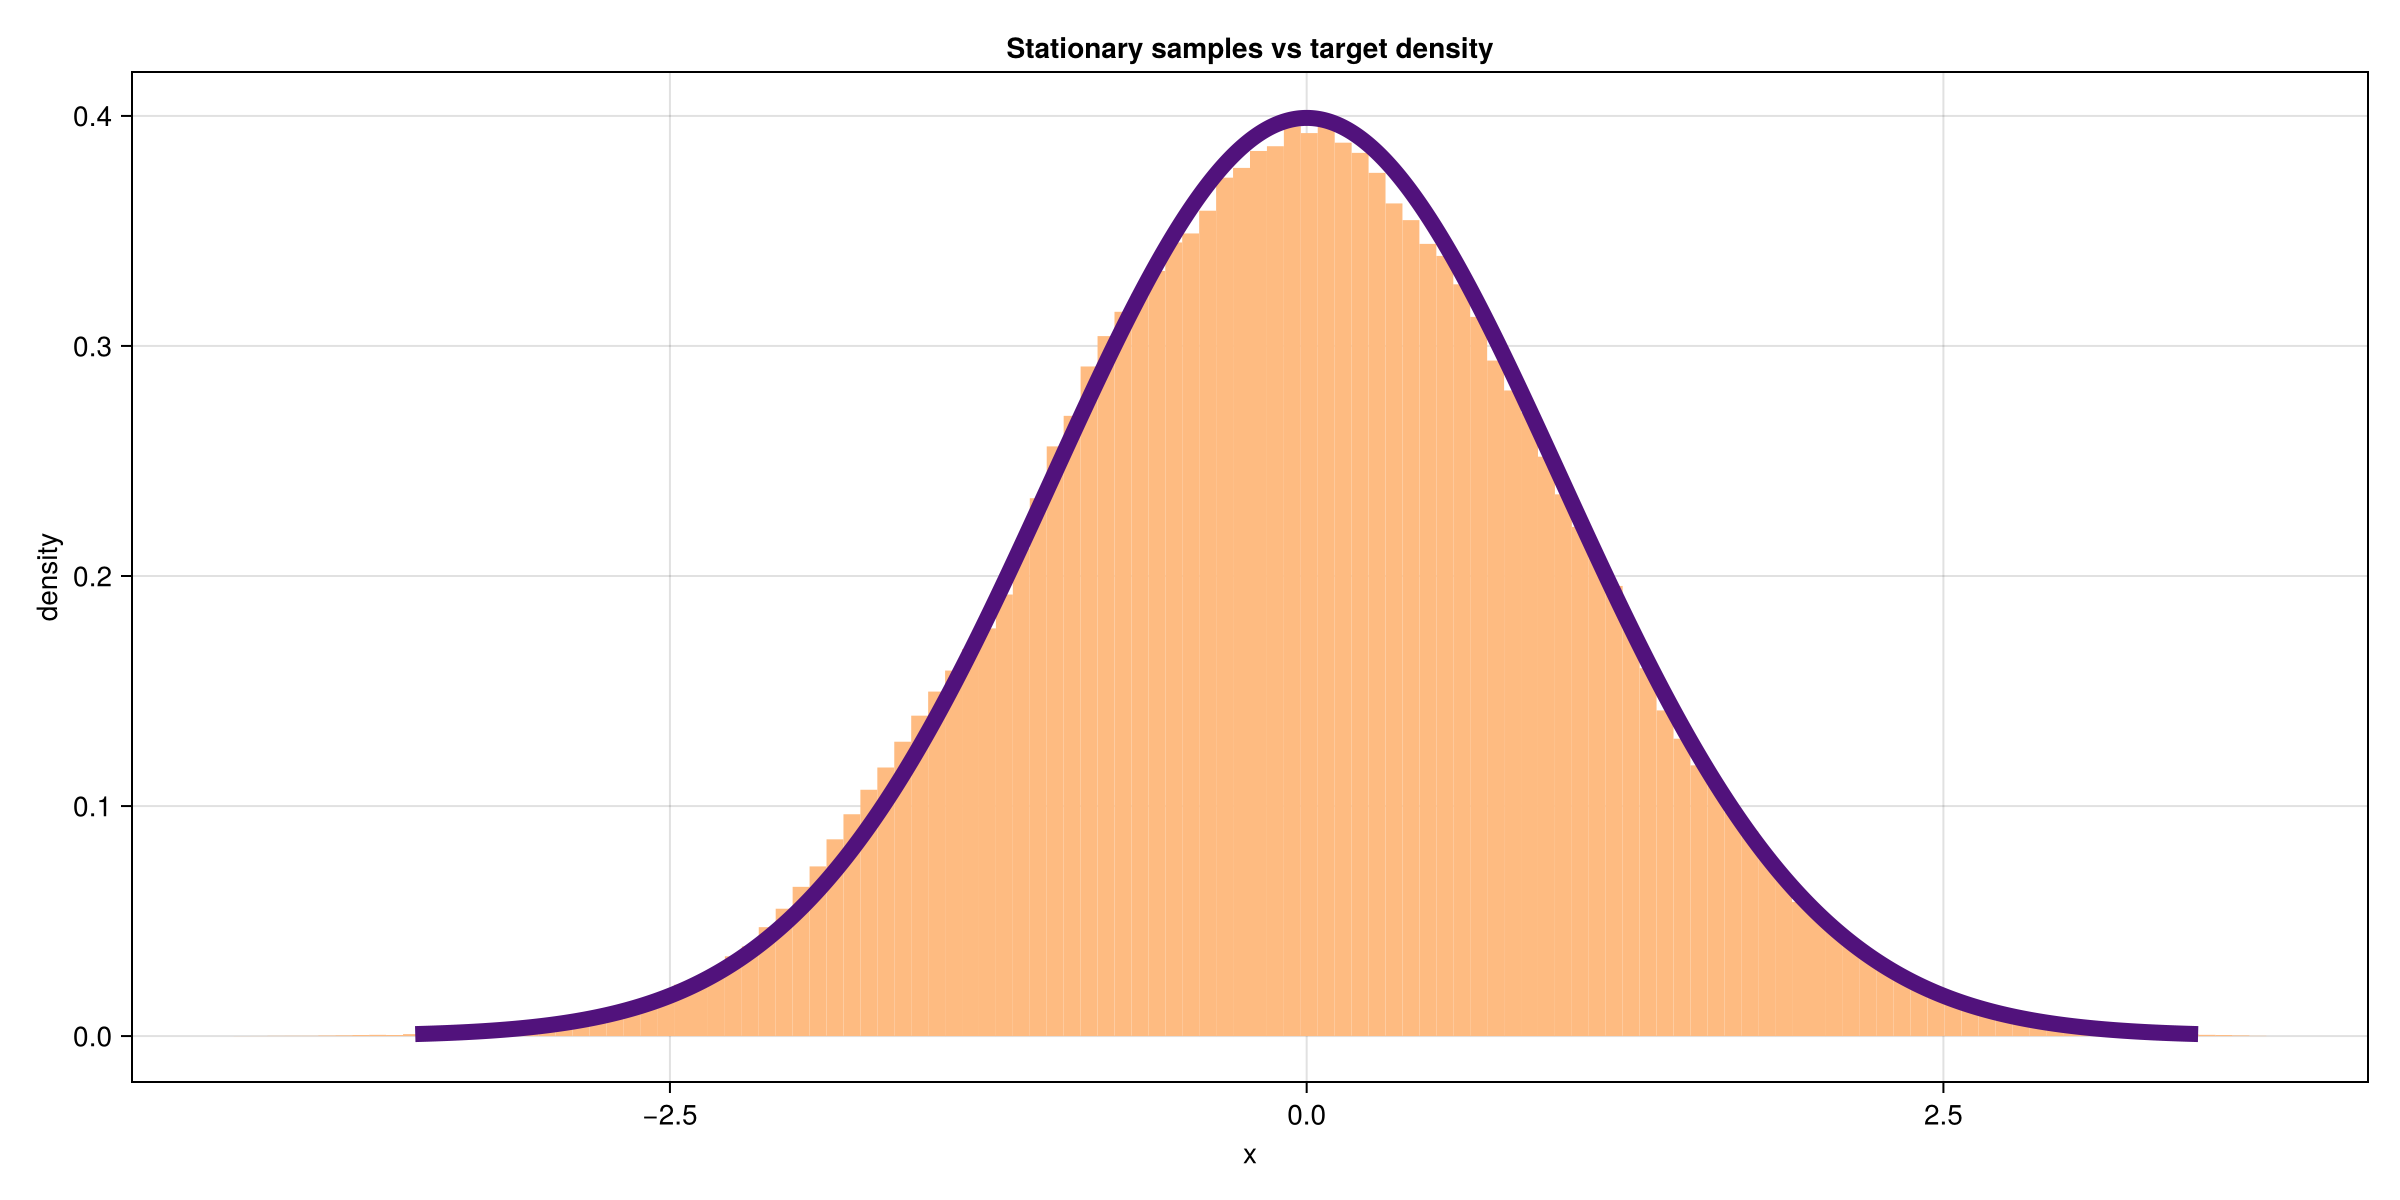

In [120]:
trapz(x::AbstractVector, y::AbstractVector) = sum((y[1:end-1] .+ y[2:end]) .* diff(x)) / 2
xmin, xmax = -3.5, 3.5
grid = collect(range(xmin, xmax; length=2000))
p_unnorm = exp.(-Φ.(grid))
Z = trapz(grid, p_unnorm)
p = p_unnorm ./ Z

fig = Figure(size = (1200, 600))

# (3) Histogram + target density overlay
ax1 = Axis(fig[1, 1], title = "Stationary samples vs target density",
           xlabel = "x", ylabel = "density")

# Histogram normalized to integrate ~ 1
hist!(ax1, vs[1:2000000]; bins=120, normalization=:pdf, color="#FEBB81")

# Overlay target density
lines!(ax1, grid, p; linewidth=8, color= "#51127C")

fig

## **Example 2**

In this example, we study the following potential:

$$
\Phi(v) = \left(v^2-2\right)^2 + \alpha v,
$$
where we set $\alpha = 0.4$. The potential looks as follows:

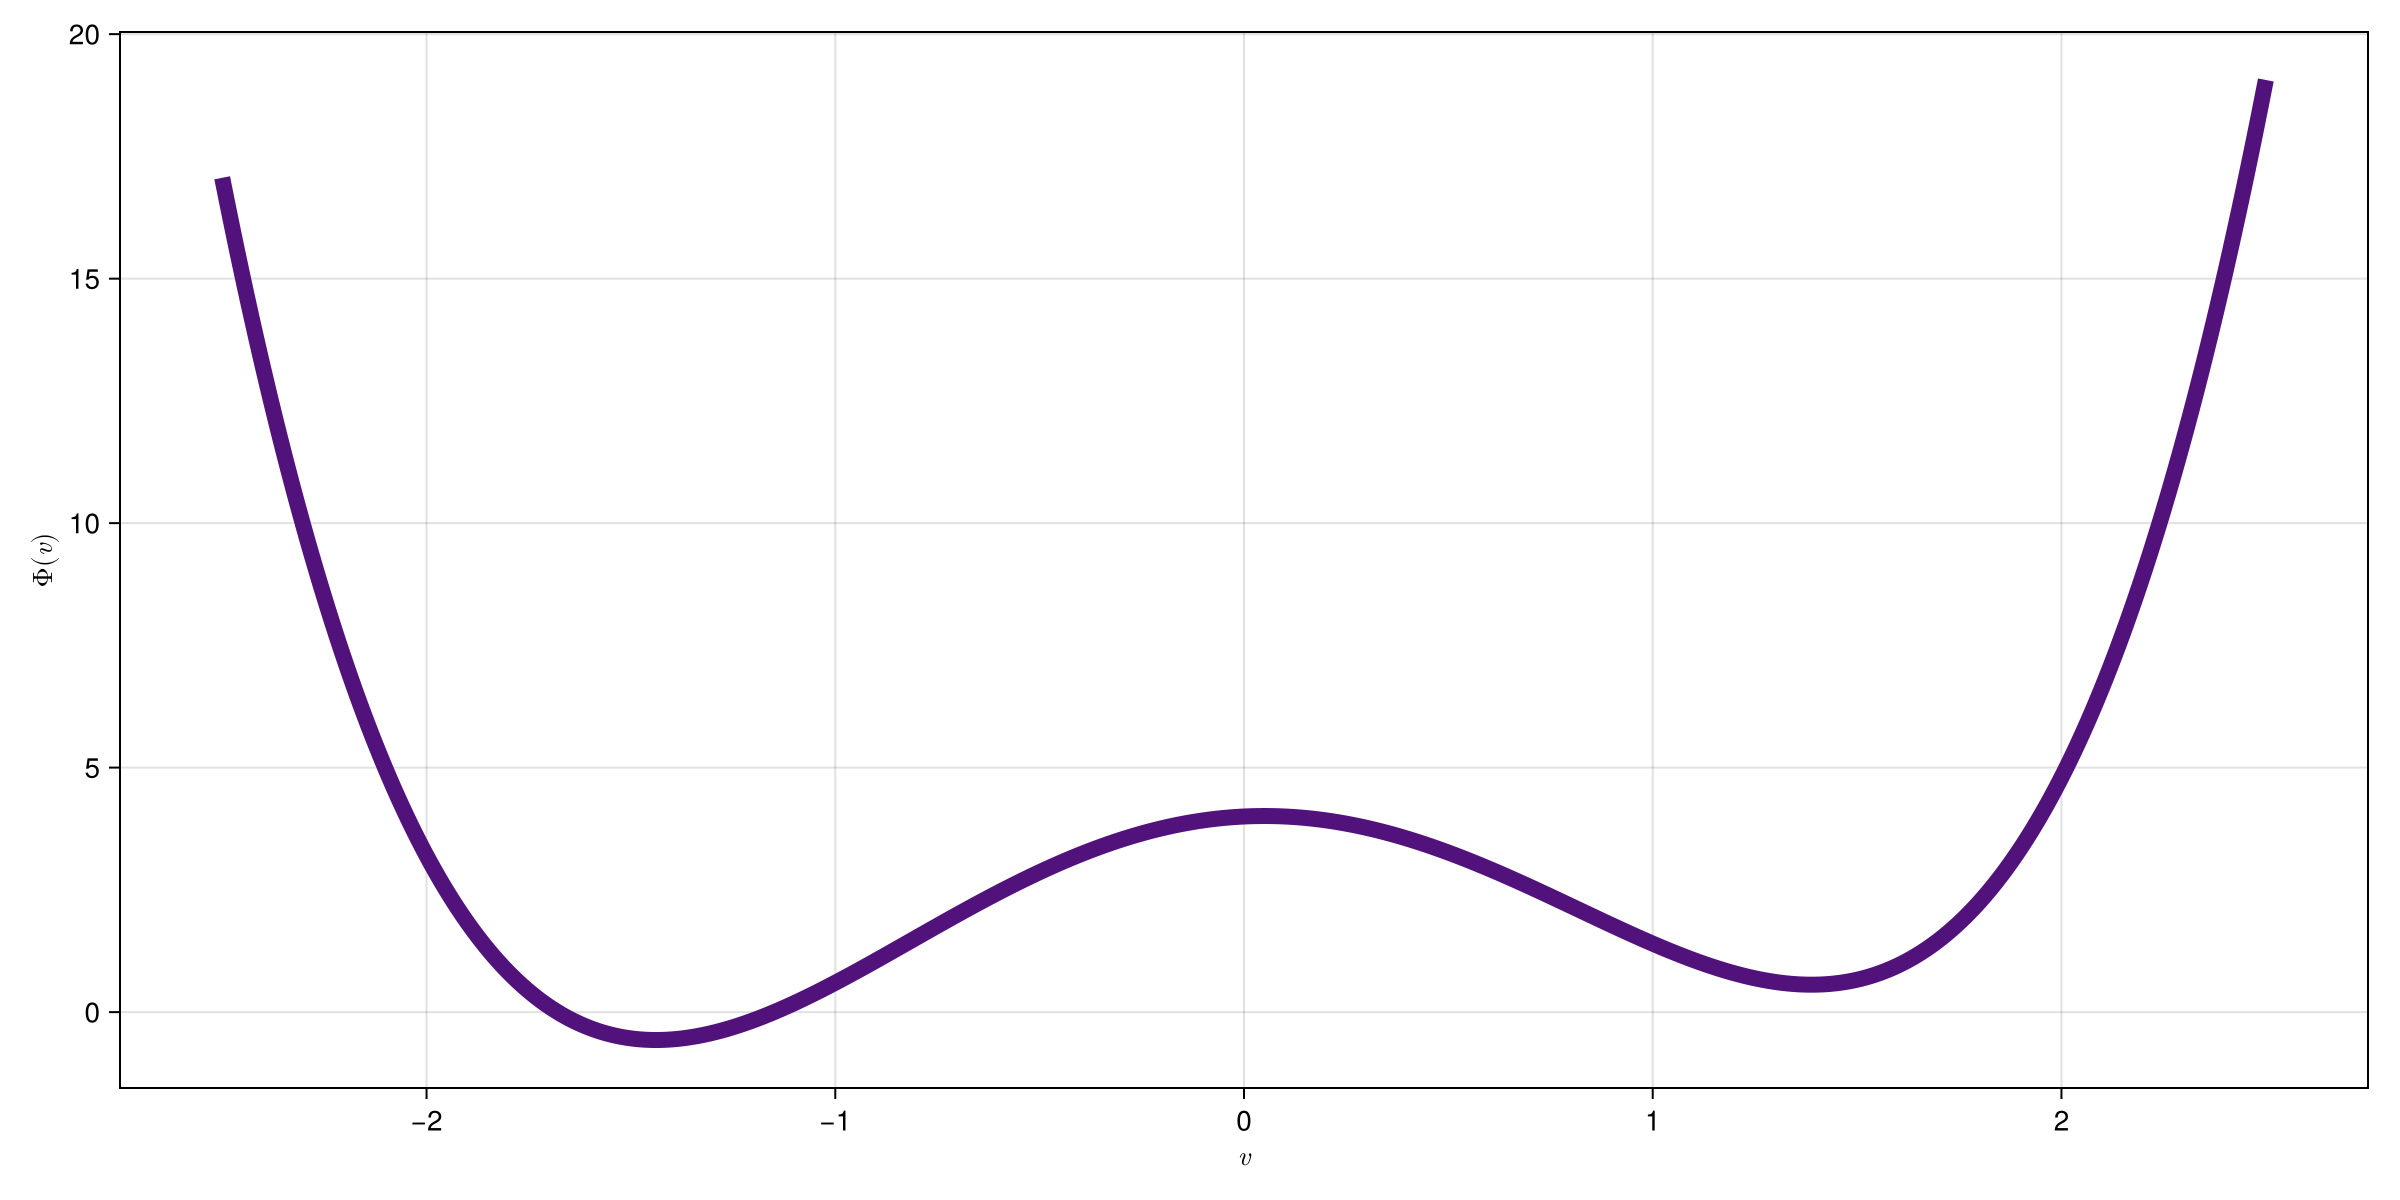

In [121]:
α = 0.4
Φ(v) = (v^2 - 2)^2 + α*v
∇Φ(v) = 4*v*(v^2 - 2) + α

fig = Figure(size = (1200, 600))

xmin, xmax = -2.5, 2.5
grid = collect(range(xmin, xmax; length=2000))
ax1 = Axis(fig[1, 1], 
           xlabel = L"v", ylabel = L"Φ(v)")
lines!(ax1, grid, Φ.(grid); linewidth=8, color= "#51127C")
fig

We are interested in sampling $\rho\propto e^{-\Phi(v)}$. We can do this by designing a Langevin equation that has $\rho$ as its invariant distribution. The resulting Langevin equation is:

$$
\dot{v} = -4v\left(v^2-2\right)-\alpha +\sqrt{2}\dot{W}
$$

In [122]:
Δt = 1e-3
J = 2_000_000
v₀ = 2.0
vs = Langevin_EM(; Δt, J, v₀);

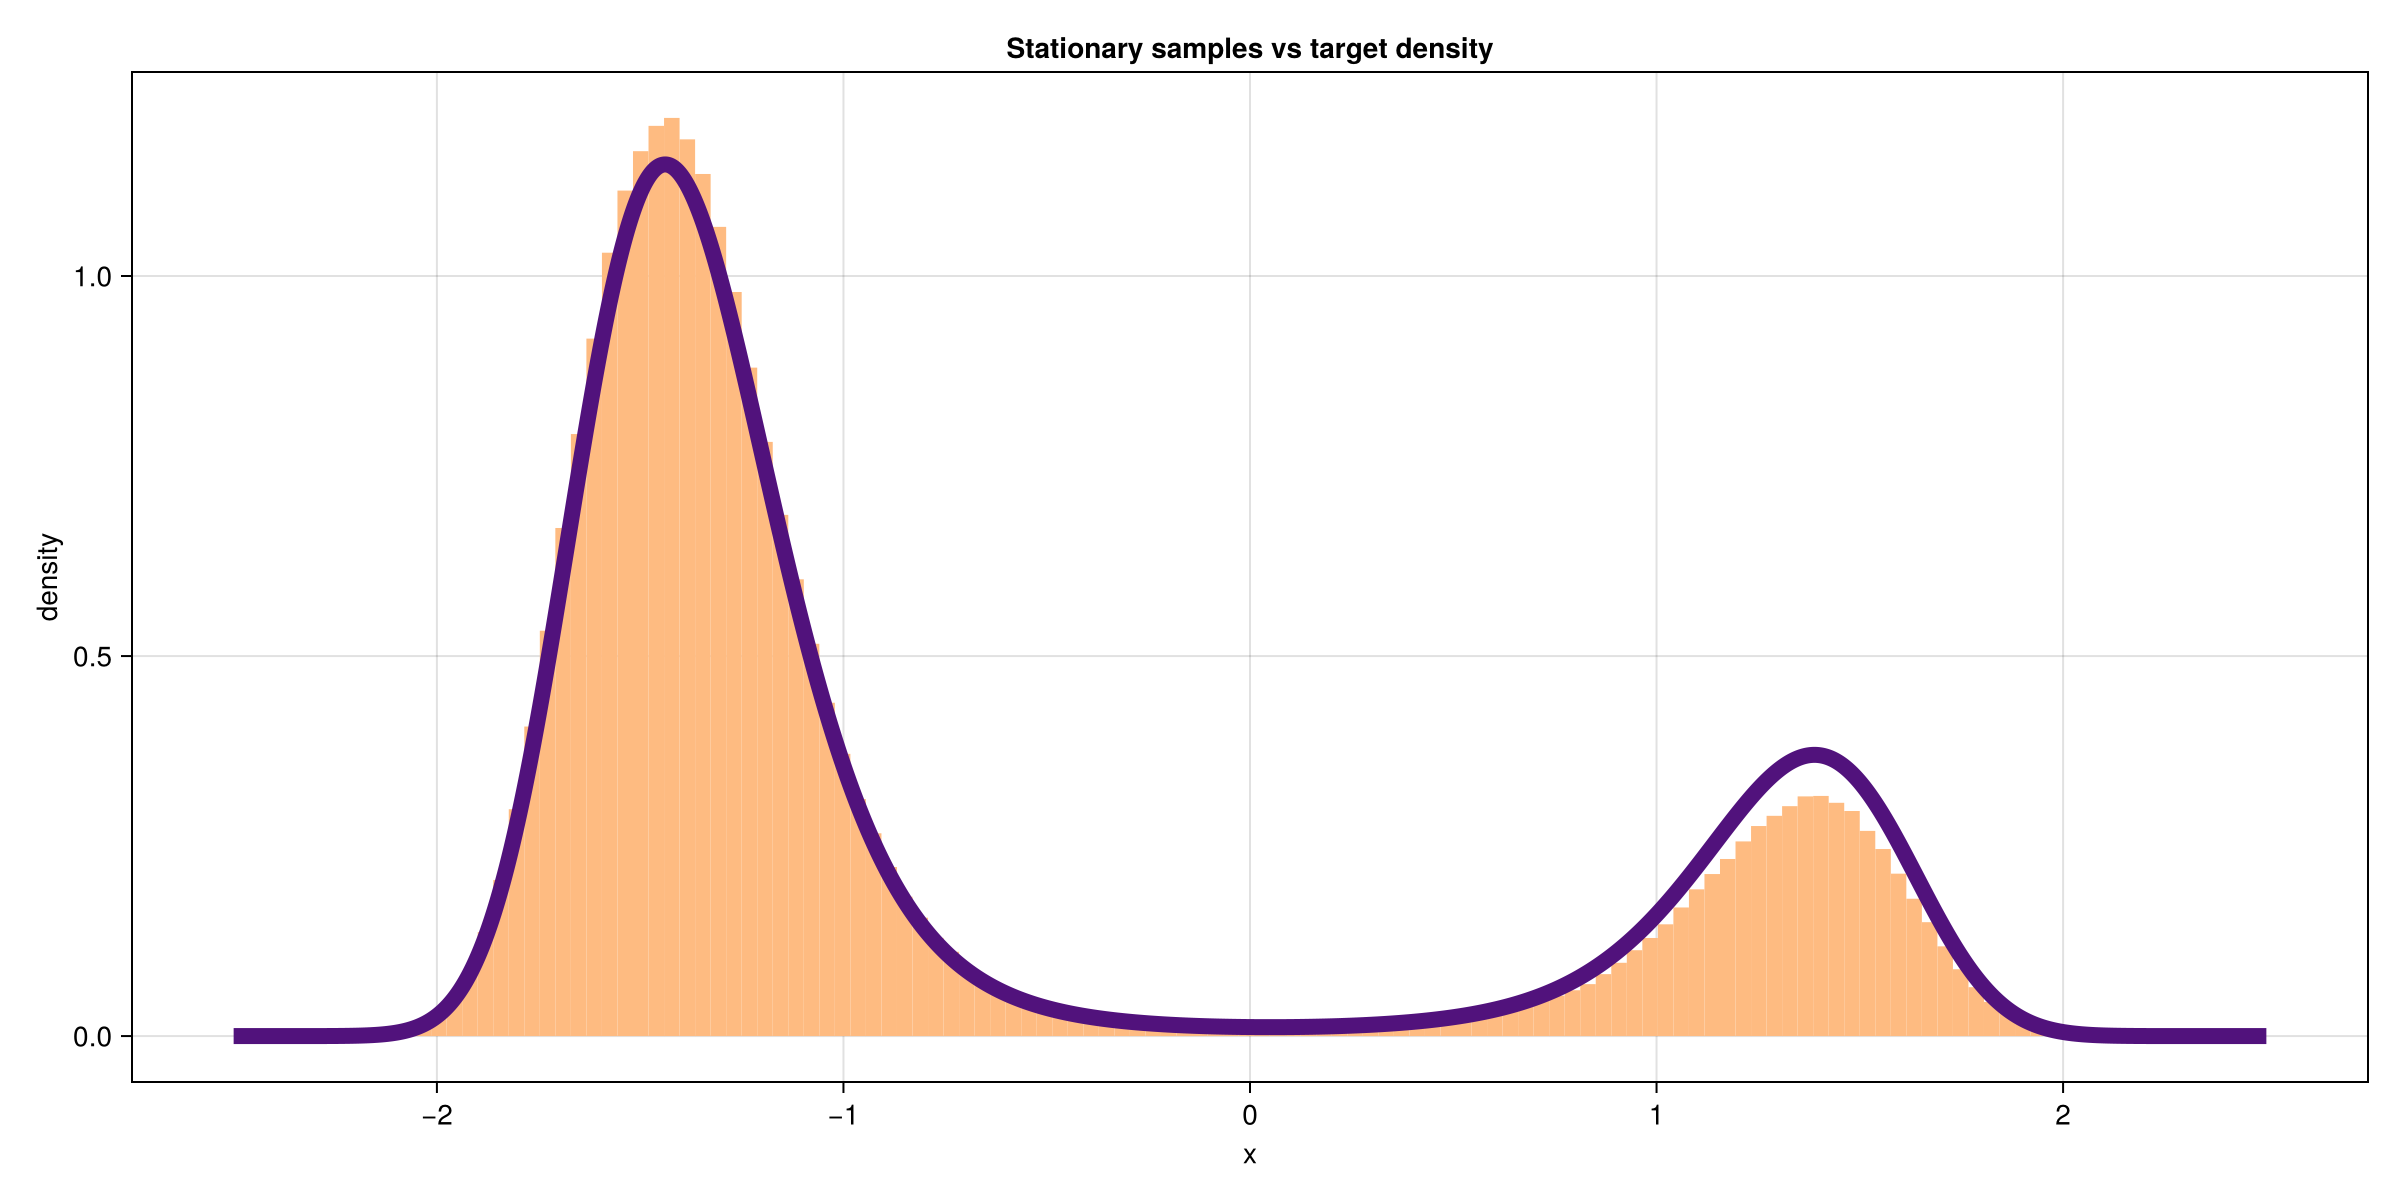

In [128]:
trapz(x::AbstractVector, y::AbstractVector) = sum((y[1:end-1] .+ y[2:end]) .* diff(x)) / 2
xmin, xmax = -2.5, 2.5
grid = collect(range(xmin, xmax; length=5000))
p_unnorm = exp.(-Φ.(grid))
Z = trapz(grid, p_unnorm)
p = p_unnorm ./ Z

fig = Figure(size = (1200, 600))

# (3) Histogram + target density overlay
ax1 = Axis(fig[1, 1], title = "Stationary samples vs target density",
           xlabel = "x", ylabel = "density")

# Histogram normalized to integrate ~ 1
hist!(ax1, vs[1:2000000]; bins=120, normalization=:pdf, color="#FEBB81")

# Overlay target density
lines!(ax1, grid, p; linewidth=8, color= "#51127C")

fig